In [2]:
import json
import re
import numpy as np
import matplotlib.pyplot as plt

# ── Load entity extraction results ──
ENTITY_DIR = "entity_extraction_output"
entity_files = {
    "Replace All": f"{ENTITY_DIR}/local_replace_all_entity_results.json",
    "Replace One": f"{ENTITY_DIR}/local_replace_one_entity_results.json",
    "Search":      f"{ENTITY_DIR}/local_search_entity_results.json",
}
entity_data = {}
for label, path in entity_files.items():
    with open(path, "r", encoding="utf-8") as f:
        entity_data[label] = json.load(f)

# ── Load original experiment files (needed for unique words) ──
EXP_DIR = "experiment_outputs"
exp_files = {
    "Replace All": f"{EXP_DIR}/local_replace_all.json",
    "Replace One": f"{EXP_DIR}/local_replace_one.json",
    "Search":      f"{EXP_DIR}/local_search.json",
}
exp_data = {}
for label, path in exp_files.items():
    with open(path, "r", encoding="utf-8") as f:
        exp_data[label] = json.load(f)

# Consistent colors
COLORS = {"Replace All": "#1f77b4", "Replace One": "#ff7f0e", "Search": "#2ca02c"}

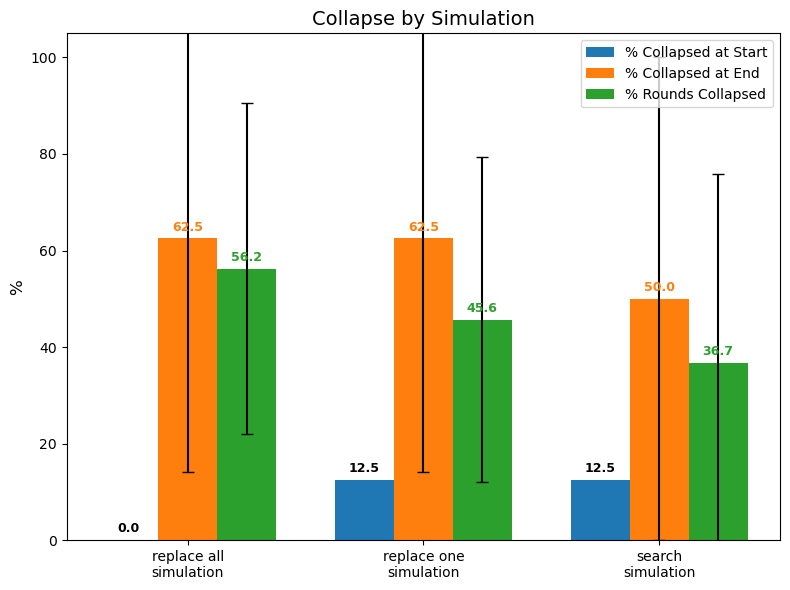

In [3]:
# ── Collapse by Simulation (bar chart) ──
# A question-round is "collapsed" when ALL responses share the same entity set.

def is_collapsed(iteration_runs):
    """True if every run in the iteration has an identical canonical entity set."""
    sets = [frozenset(r["canonical_entities"]) for r in iteration_runs]
    return len(set(sets)) == 1

def compute_collapse_metrics(experiment):
    start_collapsed = []  # 1/0 per question: collapsed at round 0?
    end_collapsed   = []  # 1/0 per question: collapsed at last round?
    pct_rounds      = []  # per question: fraction of rounds that are collapsed

    for q in experiment["questions"]:
        iters = q["iterations"]
        if not iters:
            continue

        collapsed_flags = [is_collapsed(it["runs"]) for it in iters]

        start_collapsed.append(1 if collapsed_flags[0] else 0)
        end_collapsed.append(1 if collapsed_flags[-1] else 0)
        pct_rounds.append(sum(collapsed_flags) / len(collapsed_flags) * 100)

    n = len(start_collapsed)
    return {
        "start_mean":  sum(start_collapsed) / n * 100,
        "end_mean":    sum(end_collapsed) / n * 100,
        "end_std":     np.std([c * 100 for c in end_collapsed]),
        "rounds_mean": np.mean(pct_rounds),
        "rounds_std":  np.std(pct_rounds),
    }

metrics = {label: compute_collapse_metrics(exp) for label, exp in entity_data.items()}

simulations = list(metrics.keys())
x = np.arange(len(simulations))
width = 0.25

start_means  = [metrics[s]["start_mean"]  for s in simulations]
end_means    = [metrics[s]["end_mean"]    for s in simulations]
end_stds     = [metrics[s]["end_std"]     for s in simulations]
rounds_means = [metrics[s]["rounds_mean"] for s in simulations]
rounds_stds  = [metrics[s]["rounds_std"]  for s in simulations]

fig, ax = plt.subplots(figsize=(8, 6))

bars1 = ax.bar(x - width, start_means, width, label="% Collapsed at Start", color="#1f77b4")
bars2 = ax.bar(x, end_means, width, yerr=end_stds, capsize=4, label="% Collapsed at End", color="#ff7f0e")
bars3 = ax.bar(x + width, rounds_means, width, yerr=rounds_stds, capsize=4, label="% Rounds Collapsed", color="#2ca02c")

for bar in bars1:
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 1,
            f"{bar.get_height():.1f}", ha="center", va="bottom", fontsize=9, fontweight="bold")
for bar in bars2:
    h = bar.get_height()
    ax.text(bar.get_x() + bar.get_width() / 2, h + 1,
            f"{h:.1f}", ha="center", va="bottom", fontsize=9, fontweight="bold", color="#ff7f0e")
for bar in bars3:
    h = bar.get_height()
    ax.text(bar.get_x() + bar.get_width() / 2, h + 1,
            f"{h:.1f}", ha="center", va="bottom", fontsize=9, fontweight="bold", color="#2ca02c")

ax.set_ylabel("%", fontsize=12)
ax.set_title("Collapse by Simulation", fontsize=14)
ax.set_xticks(x)
ax.set_xticklabels([f"{s.lower()}\nsimulation" for s in simulations], fontsize=10)
ax.legend(loc="upper right")
ax.set_ylim(0, 105)

plt.tight_layout()
plt.savefig("collapse_by_simulation.png", dpi=150, bbox_inches="tight")
plt.show()

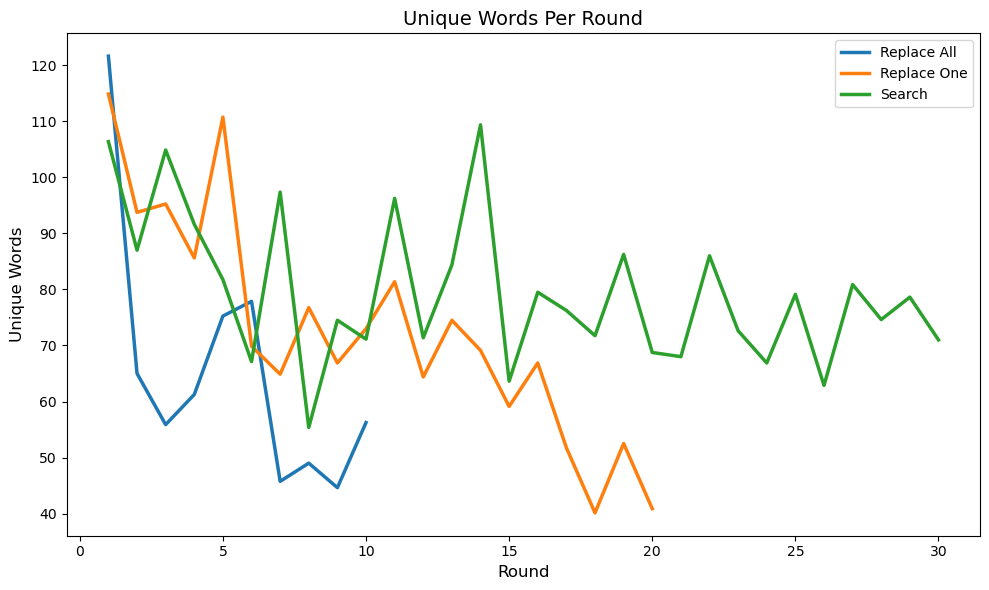

In [4]:
# ── Unique Words Per Round (line chart) ──

def tokenize(text):
    """Simple word tokenizer: lowercase alphanumeric tokens."""
    return re.findall(r"[a-z0-9]+(?:'[a-z]+)?", text.lower())

def compute_unique_words_per_round(experiment):
    """Mean unique words per round, averaged across questions."""
    max_iters = max(len(q["iterations"]) for q in experiment["questions"])
    round_means = []

    for iter_num in range(max_iters):
        counts = []
        for q in experiment["questions"]:
            if iter_num >= len(q["iterations"]):
                continue
            it = q["iterations"][iter_num]
            unique_words = set()
            for run in it["runs"]:
                unique_words.update(tokenize(run["answer"]))
            counts.append(len(unique_words))
        round_means.append(np.mean(counts) if counts else 0)

    return round_means

fig, ax = plt.subplots(figsize=(10, 6))

for label, exp in exp_data.items():
    uw = compute_unique_words_per_round(exp)
    rounds = list(range(1, len(uw) + 1))
    ax.plot(rounds, uw, linewidth=2.5, label=label, color=COLORS[label])

ax.set_xlabel("Round", fontsize=12)
ax.set_ylabel("Unique Words", fontsize=12)
ax.set_title("Unique Words Per Round", fontsize=14)
ax.legend()

plt.tight_layout()
plt.savefig("unique_words_per_round.png", dpi=150, bbox_inches="tight")
plt.show()

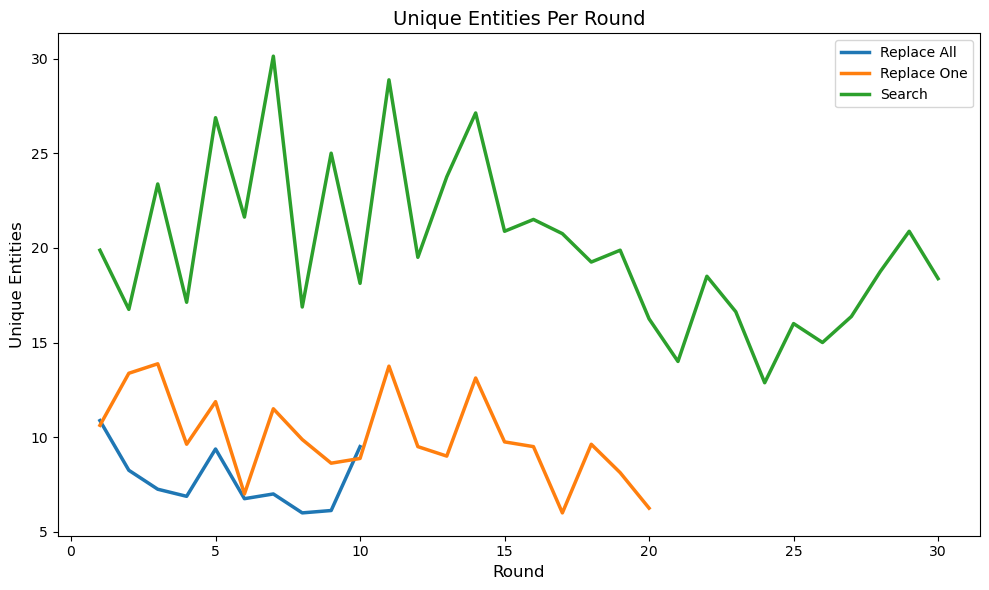

In [5]:
# ── Unique Entities Per Round (line chart) ──

fig, ax = plt.subplots(figsize=(10, 6))

for label, exp in entity_data.items():
    agg = exp["aggregate_statistics"]["mean_unique_entities_per_round"]
    rounds = list(range(1, len(agg) + 1))
    ax.plot(rounds, agg, linewidth=2.5, label=label, color=COLORS[label])

ax.set_xlabel("Round", fontsize=12)
ax.set_ylabel("Unique Entities", fontsize=12)
ax.set_title("Unique Entities Per Round", fontsize=14)
ax.legend()

plt.tight_layout()
plt.savefig("unique_entities_per_round.png", dpi=150, bbox_inches="tight")
plt.show()

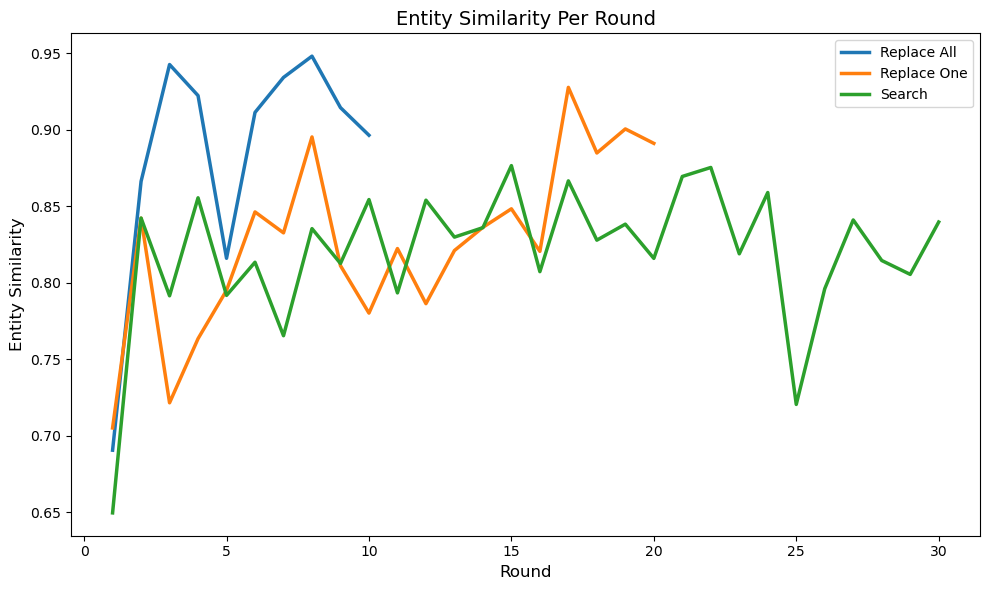

In [6]:
# ── Entity Similarity Per Round (line chart) ──

fig, ax = plt.subplots(figsize=(10, 6))

for label, exp in entity_data.items():
    agg = exp["aggregate_statistics"]["mean_entity_similarity_per_round"]
    rounds = list(range(1, len(agg) + 1))
    ax.plot(rounds, agg, linewidth=2.5, label=label, color=COLORS[label])

ax.set_xlabel("Round", fontsize=12)
ax.set_ylabel("Entity Similarity", fontsize=12)
ax.set_title("Entity Similarity Per Round", fontsize=14)
ax.legend()

plt.tight_layout()
plt.savefig("entity_similarity_per_round.png", dpi=150, bbox_inches="tight")
plt.show()